# NORMALISASI ROBUST #

In [1]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

# ==============================================================================
# DATA
# ==============================================================================
df_robust = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_robust[kolom_string] = df_robust[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_robust.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_robust

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,592938
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,962125
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,748432
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1230159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022


In [2]:
# ==============================================================================
# STANDARDISASI ROBUST
# ==============================================================================
scaler = RobustScaler()

df_robust[kolom_numerik] = scaler.fit_transform(df_robust[kolom_numerik])

print("========== HASIL STANDARDISASI ROBUST ==========")
df_robust

========== HASIL STANDARDISASI ROBUST ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.355131,-0.763722
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.281465,-0.194139
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.357889,-0.523826
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.270435,0.033304
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.315738,0.219384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-1.009871,-0.575524,-0.933854,-0.416321,-0.357101,-1.349168
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-1.005315,-0.575524,-0.783143,-0.432294,-0.419342,-1.459011
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-1.003797,-0.575524,-0.643595,-0.388590,-0.172346,-1.367275
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,-0.906606,-0.575524,7.087357,4.275868,0.435493,2.977705


* K-MEANS CLUSTERING


In [3]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [4]:
#===============================================================================
# DATA
#===============================================================================

df_robust_kmeans = df_robust.copy()
df_robust_kmeans

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.355131,-0.763722
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.281465,-0.194139
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.357889,-0.523826
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.270435,0.033304
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.315738,0.219384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-1.009871,-0.575524,-0.933854,-0.416321,-0.357101,-1.349168
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-1.005315,-0.575524,-0.783143,-0.432294,-0.419342,-1.459011
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-1.003797,-0.575524,-0.643595,-0.388590,-0.172346,-1.367275
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,-0.906606,-0.575524,7.087357,4.275868,0.435493,2.977705


========== ELBOW METHOD ==========


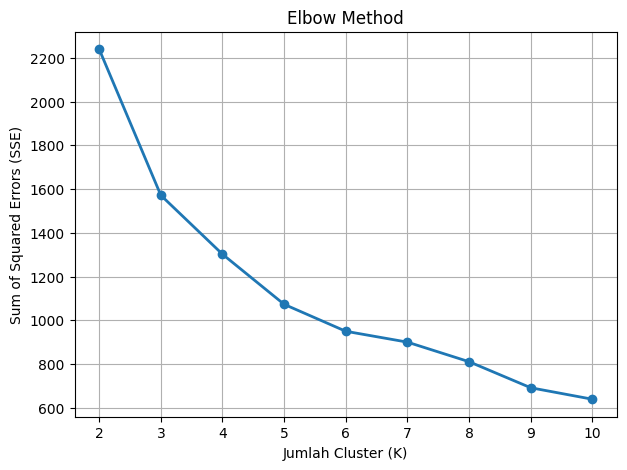

In [5]:
#===============================================================================
# 1. TENTUKAN JUMLAH CLUSTER (K)
#===============================================================================

# --------------------------
# 1.1. ELBOW METHOD
# --------------------------

print("========== ELBOW METHOD ==========")

sse = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(df_robust_kmeans[kolom_numerik])
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(7,5))
plt.plot(
    K,
    sse,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.xticks(K)
plt.grid(True)

plt.show()

In [6]:
# --------------------------
# 1.2. SILHOUETTE SCORE, DAVIES-BOULDIN INDEX, CALINSKI-HARABASZ INDEX
# --------------------------

hasil_evaluasi = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    cluster = kmeans.fit_predict(df_robust_kmeans[kolom_numerik])

    silhouette = silhouette_score(df_robust_kmeans[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_robust_kmeans[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_robust_kmeans[kolom_numerik], cluster)

    hasil_evaluasi.append({
        'Jumlah Cluster (K)': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': chi
    })

hasil_evaluasi = pd.DataFrame(hasil_evaluasi)

print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.8975,0.2676,262.7124
1,3,0.4981,0.9482,242.3319
2,4,0.4372,0.9356,212.3173
3,5,0.2316,0.9929,206.4297
4,6,0.2490,1.1085,192.5899
5,7,0.2554,1.2235,171.0762
6,8,0.2816,0.8003,166.2625
7,9,0.2624,0.8637,175.3861
8,10,0.2533,0.9288,170.3698


In [7]:
# --------------------------
# 1.3. K OPTIMAL
# --------------------------

print("========== K OPTIMAL ==========")


k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster (K)']
print("1. K Optimal berdasarkan Silhouette Score:", k_optimal)


========== K OPTIMAL ==========
1. K Optimal berdasarkan Silhouette Score: 2


In [8]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster (K)']
print("2. K Optimal berdasarkan Davies-Bouldin Index:", k_optimal)

2. K Optimal berdasarkan Davies-Bouldin Index: 2


In [9]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster (K)']
print("3. K Optimal berdasarkan Calinski-Harabasz Index:", k_optimal)

3. K Optimal berdasarkan Calinski-Harabasz Index: 2


_KLASTER OPTIMAL YANG DIGUNAKAN_

In [10]:
k = 2

In [11]:
#===============================================================================
# 2. PROSES K-MEANS CLUSTERING
#===============================================================================

# --------------------------
# 2.1. INISIALISASI MODEL & PARAMETER K-MEANS
# --------------------------
kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42
)

# --------------------------
# 2.2. FIT MODEL K-MEANS
# --------------------------
kmeans.fit(df_robust_kmeans[kolom_numerik])


#--------------------------
# 2.3. SIMPAN CENTROID
#--------------------------
centroid = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=kolom_numerik
)

centroid.insert(0, "Cluster", range(1, len(centroid) + 1))

print("========== CENTROID ==========")
display(centroid)



========== CENTROID ==========


,Cluster,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,1,0.252331,-0.081294,-0.060859,0.214059,0.290302,0.266961,0.556637,-0.029025
1,2,2.692308,0.384615,2.039484,20.337376,10.559308,1.412289,24.881229,2.918131


In [12]:
# ---------------------------
# 2.4. SIMPAN LABEL CLUSTER
# ---------------------------

print("========== LABEL CLUSTER ==========")
df_robust_kmeans['cluster_kmeans'] = kmeans.fit_predict(df_robust_kmeans[kolom_numerik])
df_robust_kmeans["cluster_kmeans"] = kmeans.labels_ + 1
df_robust_kmeans

========== LABEL CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_kmeans
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.355131,-0.763722,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.281465,-0.194139,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.357889,-0.523826,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.270435,0.033304,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.315738,0.219384,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-1.009871,-0.575524,-0.933854,-0.416321,-0.357101,-1.349168,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-1.005315,-0.575524,-0.783143,-0.432294,-0.419342,-1.459011,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-1.003797,-0.575524,-0.643595,-0.388590,-0.172346,-1.367275,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,-0.906606,-0.575524,7.087357,4.275868,0.435493,2.977705,1


In [13]:
#===============================================================================
# 2.5. SIMPAN HASIL CLUSTERING K-MEANS (DATA ASLI)
#===============================================================================
df_hasil = pd.read_csv('dataset_baru.csv').copy()

df_hasil["cluster_kmeans"] = kmeans.labels_ + 1

print("========== HASIL CLUSTERING K-MEANS ==========")
display(df_hasil)

========== HASIL CLUSTERING K-MEANS ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_kmeans
0,35,JAWA TIMUR,3501,PACITAN,2018,9,15,347,141,619,41173,292,592938,1
1,35,JAWA TIMUR,3502,PONOROGO,2018,12,19,519,129,990,46778,479,962125,1
2,35,JAWA TIMUR,3503,TRENGGALEK,2018,3,19,384,227,792,40464,285,748432,1
3,35,JAWA TIMUR,3504,TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547,1
4,35,JAWA TIMUR,3505,BLITAR,2018,6,18,540,233,837,65232,392,1230159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733,1
264,35,JAWA TIMUR,3578,SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022,1


In [14]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil.to_csv('data_cluster_kmeans.csv', index=False)

In [15]:
# ---------------------------
# JUMLAH ANGGOTA CLUSTER
# ---------------------------

jumlah_cluster = (
    df_hasil["cluster_kmeans"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

cluster_kmeans
1    264
2      2
Name: count, dtype: int64

In [16]:
#===============================================================================
# 3. EVALUASI HASIL CLUSTERING K-MEANS
#===============================================================================

silhouette = silhouette_score(
    df_robust_kmeans[kolom_numerik],
    df_robust_kmeans['cluster_kmeans']
)

dbi = davies_bouldin_score(
    df_robust_kmeans[kolom_numerik],
    df_robust_kmeans['cluster_kmeans']
)

chi = calinski_harabasz_score(
    df_robust_kmeans[kolom_numerik],
    df_robust_kmeans['cluster_kmeans']
)

print("========== HASIL EVALUASI K-MEANS ==========")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")

========== HASIL EVALUASI K-MEANS ==========
Silhouette Score        : 0.8975
Davies-Bouldin Index    : 0.2676
Calinski-Harabasz Index : 262.7124


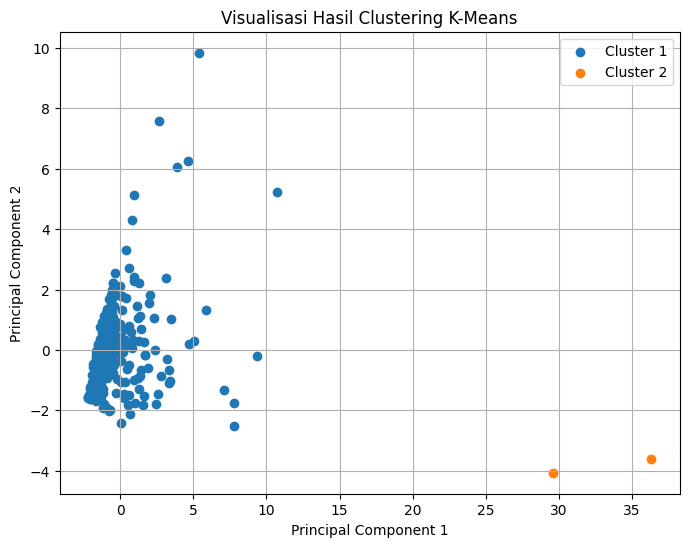

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_robust_kmeans[kolom_numerik])

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["Cluster"] = kmeans.labels_ + 1

plt.figure(figsize=(8,6))

for cluster in sorted(df_pca["Cluster"].unique()):
    subset = df_pca[df_pca["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}"
    )

plt.title("Visualisasi Hasil Clustering K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# ==========================================================
# 1. EVALUASI K SUB-CLUSTER
# ==========================================================

evaluasi_subcluster = []
k_optimal_subcluster = {}

max_k = 10

for cluster in sorted(df_hasil['cluster_kmeans'].unique()):

    # Mengambil data berdasarkan cluster utama
    data_cluster = df_hasil.loc[
        df_hasil['cluster_kmeans'] == 1,
        kolom_numerik
    ]

    # K maksimal tidak boleh >= jumlah data
    max_k_cluster = min(max_k, len(data_cluster) - 1)

    for k in range(2, max_k_cluster + 1):

        kmeans_sub = KMeans(
            n_clusters=k,
            init='k-means++',
            random_state=42
        )

        labels_sub = kmeans_sub.fit_predict(
            data_cluster
        )

        silhouette = silhouette_score(
            data_cluster,
            labels_sub
        )

        dbi = davies_bouldin_score(
            data_cluster,
            labels_sub
        )

        chi = calinski_harabasz_score(
            data_cluster,
            labels_sub
        )

        evaluasi_subcluster.append({
            'Cluster Utama': cluster,
            'Jumlah Sub Cluster (K)': k,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': dbi,
            'Calinski-Harabasz Index': chi
        })


# ==========================================================
# 2. TABEL HASIL EVALUASI
# ==========================================================

evaluasi_subcluster_df = pd.DataFrame(
    evaluasi_subcluster
)

evaluasi_subcluster_df = (
    evaluasi_subcluster_df
    .sort_values([
        'Cluster Utama',
        'Jumlah Sub Cluster (K)'
    ])
    .reset_index(drop=True)
)

print("\n=== HASIL EVALUASI SUB-CLUSTER ===")
display(
    evaluasi_subcluster_df.round(4)
)


=== HASIL EVALUASI SUB-CLUSTER ===


,Cluster Utama,Jumlah Sub Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1,2,0.4630,0.7765,288.3963
1,1,3,0.5278,0.5884,540.5667
2,1,4,0.5271,0.6067,704.6540
3,1,5,0.5987,0.5405,997.5063
4,1,6,0.6029,0.5057,1041.3240
5,1,7,0.5917,0.5983,995.1659
6,1,8,0.5200,0.6707,1106.4651
7,1,9,0.5111,0.7938,1104.4047
8,1,10,0.5107,0.7772,1064.3638
9,2,2,0.4630,0.7765,288.3963


In [19]:
# --------------------------
# K OPTIMAL SUB-CLUSTER
# --------------------------

print("========== K OPTIMAL SUB-CLUSTER ==========")

hasil_cluster = evaluasi_subcluster_df[
    evaluasi_subcluster_df['Cluster Utama'] == 1
    ]

print(f"\n========== CLUSTER UTAMA ==========")

k_optimal_silhouette = hasil_cluster.loc[
        hasil_cluster['Silhouette Score'].idxmax(),
        'Jumlah Sub Cluster (K)'
    ]

print(
        "1. K Optimal berdasarkan Silhouette Score:",
        k_optimal_silhouette
    )


k_optimal_dbi = hasil_cluster.loc[
        hasil_cluster['Davies-Bouldin Index'].idxmin(),
        'Jumlah Sub Cluster (K)'
    ]

print(
        "2. K Optimal berdasarkan Davies-Bouldin Index:",
        k_optimal_dbi
    )


k_optimal_chi = hasil_cluster.loc[
        hasil_cluster['Calinski-Harabasz Index'].idxmax(),
        'Jumlah Sub Cluster (K)'
    ]

print(
        "3. K Optimal berdasarkan Calinski-Harabasz Index:",
        k_optimal_chi
    )

========== K OPTIMAL SUB-CLUSTER ==========

========== CLUSTER UTAMA ==========
1. K Optimal berdasarkan Silhouette Score: 6
2. K Optimal berdasarkan Davies-Bouldin Index: 6
3. K Optimal berdasarkan Calinski-Harabasz Index: 8


In [20]:
# ==========================================================
# 1. CLUSTERING SUB-CLUSTER
# ==========================================================

hasil_subcluster = []

for cluster in sorted(df_hasil['cluster_kmeans'].unique()):

    # Ambil data berdasarkan cluster utama
    df_cluster = df_hasil[
        df_hasil['cluster_kmeans'] == cluster
    ].copy()

    jumlah_data = len(df_cluster)

    # K sub-cluster
    k_sub = 6

    # Jika jumlah data kurang dari K,
    # sub-clustering tidak dapat dilakukan
    if jumlah_data < k_sub:

        print(
            f"Cluster Utama {cluster}: "
            f"{jumlah_data} data → tidak dilakukan sub-clustering"
        )

        df_cluster['sub_cluster'] = 1

        hasil_subcluster.append(df_cluster)

        continue

    # Mengambil data numerik
    X_sub = df_cluster[kolom_numerik]

    # K-Means sub-cluster
    kmeans_sub = KMeans(
        n_clusters=k_sub,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    sub_cluster = kmeans_sub.fit_predict(X_sub)

    # Label sub-cluster dimulai dari 1
    df_cluster['sub_cluster'] = sub_cluster + 1

    # Simpan hasil
    hasil_subcluster.append(df_cluster)


# ==========================================================
# 2. GABUNGKAN HASIL SUB-CLUSTER
# ==========================================================

hasil_subcluster = pd.concat(
    hasil_subcluster,
    ignore_index=True
)


# ==========================================================
# 3. JUMLAH ANGGOTA SUB-CLUSTER
# ==========================================================

jumlah_anggota_subcluster = (
    hasil_subcluster
    .groupby(
        [
            'cluster_kmeans',
            'sub_cluster'
        ]
    )
    .size()
    .reset_index(
        name='Jumlah Anggota'
    )
    .sort_values(
        [
            'cluster_kmeans',
            'sub_cluster'
        ]
    )
    .reset_index(drop=True)
)

print("========== JUMLAH ANGGOTA SUB-CLUSTER ==========")

display(jumlah_anggota_subcluster)


# ==========================================================
# 4. TABEL HASIL LABELING
# ==========================================================

df_hasil_sub = (
    hasil_subcluster
    .sort_values(
        [
            'cluster_kmeans',
            'sub_cluster'
        ]
    )
    .reset_index(drop=True)
)

print("========== HASIL LABELING SUB-CLUSTER ==========")

display(df_hasil_sub)

Cluster Utama 2: 2 data → tidak dilakukan sub-clustering
========== JUMLAH ANGGOTA SUB-CLUSTER ==========


,cluster_kmeans,sub_cluster,Jumlah Anggota
0,1,1,93
1,1,2,49
2,1,3,13
3,1,4,28
4,1,5,75
5,1,6,6
6,2,1,2


========== HASIL LABELING SUB-CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_kmeans,sub_cluster
0,35,JAWA TIMUR,3504,TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547,1,1
1,35,JAWA TIMUR,3505,BLITAR,2018,6,18,540,233,837,65232,392,1230159,1,1
2,35,JAWA TIMUR,3508,LUMAJANG,2018,3,22,416,105,990,64334,222,1124756,1,1
3,35,JAWA TIMUR,3513,PROBOLINGGO,2018,13,20,817,82,1053,45539,283,1124989,1,1
4,35,JAWA TIMUR,3516,MOJOKERTO,2018,10,17,636,136,1176,46130,473,1120249,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3507,MALANG,2023,0,39,1369,0,3698,830242,2007,2711102,1,6
262,35,JAWA TIMUR,3578,SURABAYA,2023,41,22,1891,0,10883,875411,5675,3009286,1,6
263,35,JAWA TIMUR,3578,SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022,1,6
264,35,JAWA TIMUR,3578,SURABAYA,2021,41,22,1950,5299,9444,479,49775,2970952,2,1


In [21]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil_sub.to_csv('data_sub-cluster_kmeans.csv', index=False)

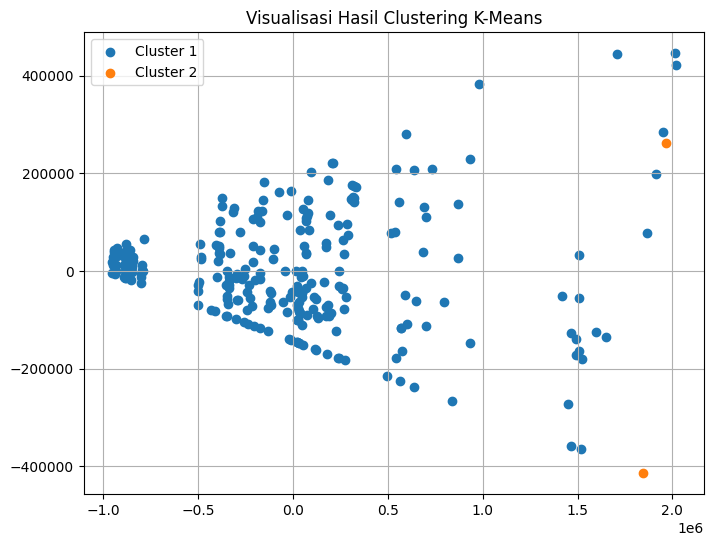

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=8)
pca_result = pca.fit_transform(df_hasil[kolom_numerik])

df_pca = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(8)])
df_pca["sub_cluster"] = kmeans.labels_ + 1

plt.figure(figsize=(8,6))

for sub_cluster in sorted(df_pca["sub_cluster"].unique()):
    subset = df_pca[df_pca["sub_cluster"] == sub_cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {sub_cluster}"
    )

plt.title("Visualisasi Hasil Clustering K-Means")
plt.legend()
plt.grid(True)
plt.show()